We use :

-A base Stable Diffusion XL model (sd_xl_base_1.0)
-A ControlNet model (t2i-adapter-sketch-sdxl-1.0)
-Canny edge preprocessing on an input image

In [ ]:
!pip install matplotlib

In [1]:
from diffusers import StableDiffusionXLAdapterPipeline, T2IAdapter
from diffusers.utils import load_image
import torch
import cv2
from PIL import Image
import numpy as np

c:\Users\DELL\anaconda3\envs\controlnetenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
A matching Triton is not available, some optimizations will not be enabled.
Error caught was: No module named 'triton'


In [2]:
# --- Load & preprocess input image ---
input_path = "sample img/street_layout_grayscale.png"
input_image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(input_image, 186, 200)
edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
edge_image = Image.fromarray(edges_rgb)

Download the models

In [35]:
from huggingface_hub import snapshot_download
# Download SDXL Base 1.0 (Stable Diffusion)
sdxl_path = snapshot_download(
    repo_id="stabilityai/stable-diffusion-xl-base-1.0",
    local_dir="C:/GITCLONE/gg_worlds/controlnet/buildingfootprint/models/sdxlbase/sdxl-1.0",
    local_dir_use_symlinks=False
)

c:\Users\DELL\anaconda3\envs\controlnetenv\lib\site-packages\huggingface_hub\file_download.py:933: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(
Fetching 57 files:   0%|          | 0/57 [00:00<?, ?it/s]Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install 

In [ ]:
from huggingface_hub import snapshot_download

# Download T2I-Adapter Sketch for SDXL (ControlNet)
controlnet_path = snapshot_download(
    repo_id="TencentARC/t2i-adapter-sketch-sdxl-1.0",
    local_dir="C:/Users/DELL/OneDrive/Masaüstü/Trainedmodels/models/tencent_controlnet_sketch",
    local_dir_use_symlinks=False
)

print("✅ Download complete.")
print("SDXL saved to:", sdxl_path)
print("ControlNet saved to:", controlnet_path)


c:\Users\DELL\anaconda3\envs\controlnetenv\lib\site-packages\huggingface_hub\file_download.py:933: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(
Fetching 57 files:   2%|▏         | 1/57 [00:00<00:17,  3.26it/s]Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip 

✅ Download complete.
SDXL saved to: C:\Users\DELL\OneDrive\Masaüstü\Trainedmodels\models\sdxl-base\t2i-adapter-sketch-sdxl-1.0
ControlNet saved to: C:\Users\DELL\OneDrive\Masaüstü\Trainedmodels\models\tencent_controlnet_sketch


In [18]:
# --- Load Adapter ---
adapter = T2IAdapter.from_pretrained(
    r"C:\Users\DELL\OneDrive\Masaüstü\Trainedmodels\models\tencent_controlnet_sketch",
    torch_dtype=torch.float16
)

In [36]:
# 🧪 Debug prints before loading the pipeline
print("📂 Files in model dir:", os.listdir("models/sdxlbase/sdxl-1.0"))
print("📦 Adapter class:", adapter.__class__)
pipe = StableDiffusionXLAdapterPipeline.from_pretrained(
    sdxl_path,
    adapter=adapter,
    torch_dtype= torch.float16,
    local_files_only=True,
    use_safetensors=True 

).to("cuda")


📂 Files in model dir: ['.cache', '.gitattributes', '01.png', 'comparison.png', 'LICENSE.md', 'model_index.json', 'pipeline.png', 'README.md', 'scheduler', 'sd_xl_base_1.0.safetensors', 'sd_xl_base_1.0_0.9vae.safetensors', 'sd_xl_offset_example-lora_1.0.safetensors', 'text_encoder', 'text_encoder_2', 'tokenizer', 'tokenizer_2', 'unet', 'vae', 'vae_1_0', 'vae_decoder', 'vae_encoder']
📦 Adapter class: <class 'diffusers.models.adapter.T2IAdapter'>


Loading pipeline components...: 100%|██████████| 7/7 [00:24<00:00,  3.55s/it]


In [37]:
# --- Set prompt ---
positive_prompt = ("Overhead city map showing only building footprints. "
                   "The input is a street layout on a topography. "
                   "Generate solid footprints aligned with the roads. "
                   "Only black and white. No roads, no shading, no color. "
                   "Technical line drawing, vector-style schematic.")
negative_prompt = ("realistic, render, colored, shaded, texture, blurry, 3d, shadows, "
                   "painterly, smooth shading, thick lines, messy lines, fill, noise, "
                   "satellite, paint, artistic sketch, noise, color, roads, cars, people, "
                   "trees, shading, color, realistic, texture, landscape, 3D, satellite, blurry, labels")


In [38]:
# --- Inference ---
output = pipe(
    prompt=positive_prompt,
    negative_prompt=negative_prompt,
    image=edge_image,
    num_inference_steps=40,
    guidance_scale=0.85
)

100%|██████████| 40/40 [00:12<00:00,  3.17it/s]


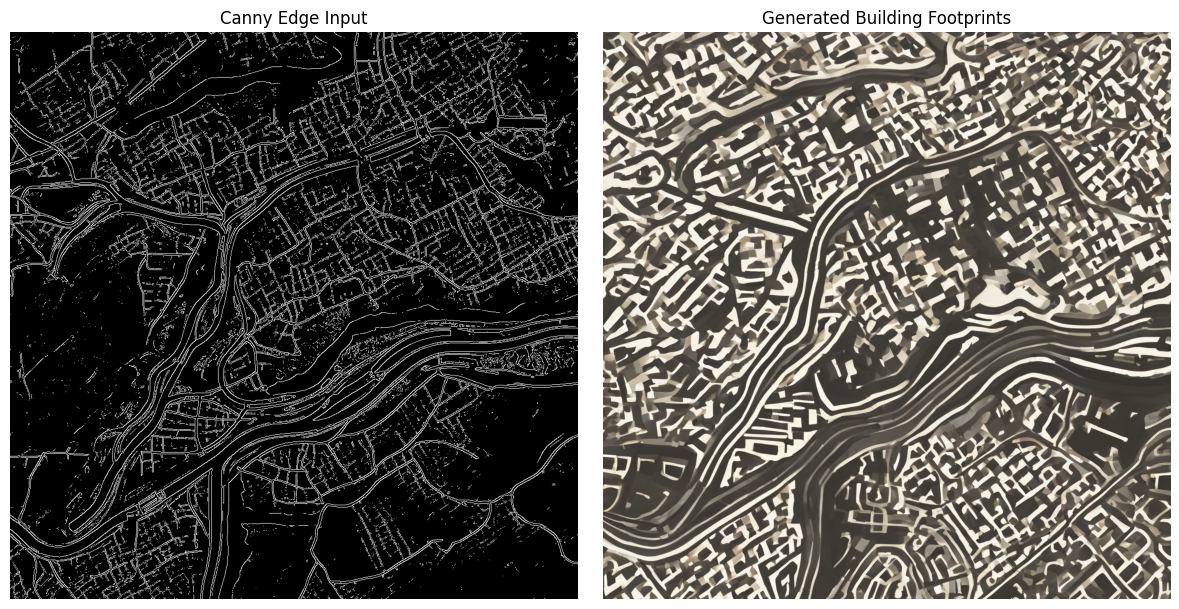

In [42]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Input edge image
axs[0].imshow(edge_image)
axs[0].set_title("Canny Edge Input")
axs[0].axis("off")

# Output image
axs[1].imshow(output.images[0])
axs[1].set_title("Generated Building Footprints")
axs[1].axis("off")

plt.tight_layout()
plt.show()



In [ ]:
# --- Save result ---
output.images[0].save("output_building_footprints.png")